In [1]:
import numpy as np
from matplotlib import pyplot as plt
from scipy import sparse as sp
import cv2

1. Lecture de l’image à segmenter (en niveaux de gris) et normalisation des niveaux de gris entre 0 et 1.

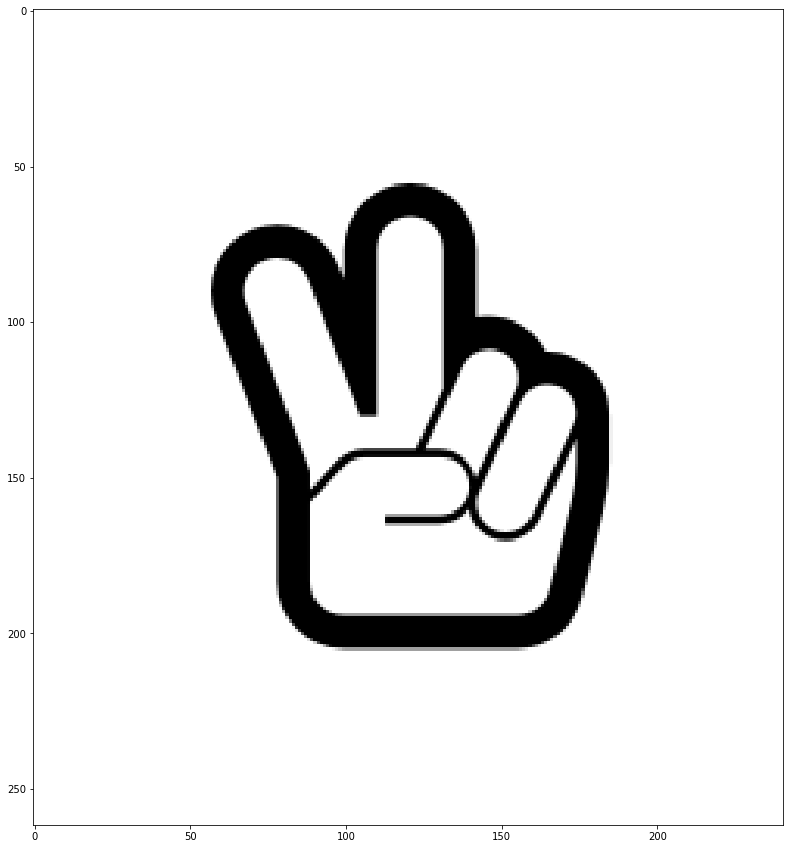

In [2]:
goutte=cv2.imread("im7.png",cv2.IMREAD_GRAYSCALE)
norm_goutte=cv2.normalize(goutte,None, 0, 1.0, cv2.NORM_MINMAX,dtype=cv2.CV_32F)
plt.figure(figsize=(15,15))
plt.imshow(norm_goutte,'gray')

2. Initialisation du snake :

    • On prendra par exemple comme initialisation un cercle centré au centre de l’image, défini sur K points

    • En superposant le snake initial à l’image, assurez-vous qu’il englobe l’objet à segmenter

    • Le snake sera défini à partir de ses coordonnées cartésiennes, stockées dans des variables séparées (par exemple, x et y)

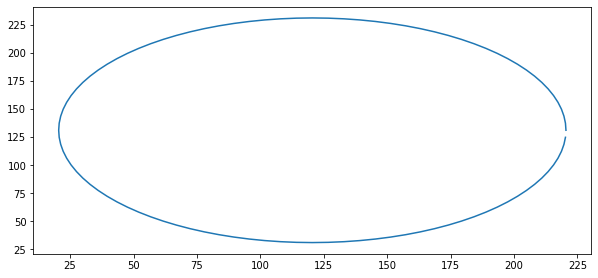

In [3]:
n = len(norm_goutte)
p = len(norm_goutte[1])
K = 100
rayon = 100
pas = 2*np.pi/K
snakeX = []
snakeY = []
for k in range(K):
    teta = k*pas
    snakeX.append(p/2 + rayon * np.cos(teta))
    snakeY.append(n/2 + rayon * np.sin(teta))
plt.figure(figsize=(10,10))
plt.subplot(211)
plt.plot(snakeX,snakeY)

Création des contours

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


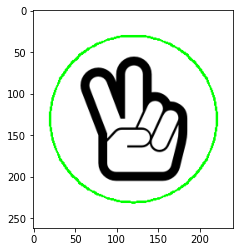

In [4]:
new_goutte = norm_goutte
snake = list()
snakes = np.zeros((K,1,2))
snakes[:,0,0] = snakeX
snakes[:,0,1] = snakeY

snake.append(snakes.astype(int))
goutte_w_contours = cv2.drawContours(cv2.cvtColor(new_goutte,cv2.COLOR_GRAY2BGR), contours=snake, contourIdx=-1, color=(0,255, 0), thickness=2, lineType=cv2.LINE_AA)
plt.figure()
plt.imshow(goutte_w_contours)
plt.show()

3. Initialisation de l'algorithme : 
    
    • Choix des paramètres alpha, Beta, gamma et delta_t

    • Calcul de toutes les grandeurs qui n’évolueront pas lors du processus itératif (gradient(s) de l’image, opérateurs différentiels)
    
    • Définition du critère d’arrêt

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


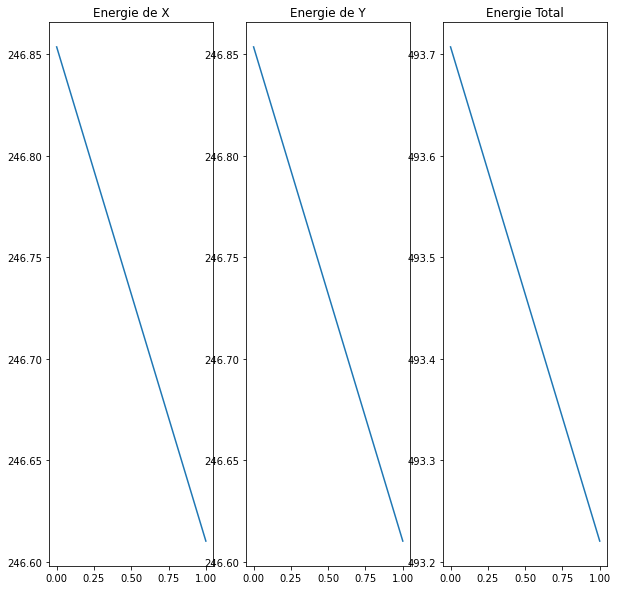

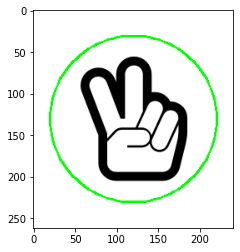

In [5]:
alpha = 0.25
beta = 0.05
gamma = 1.7
delta_t = 0.5
D2 = np.diag(np.ones(K-1),1)-np.diag(np.ones(K)*2)+np.diag(np.ones(K-1),-1)
D2[0,K-1] = 1
D2[K-1,0] = 1
D4 =  np.diag(np.ones(K-2),2)-np.diag(np.ones(K-1)*4,1)+np.diag(np.ones(K)*6)-np.diag(np.ones(K-1)*4,-1)+np.diag(np.ones(K-2),-2)
D4 = D4 + np.diag(np.ones(2),K-2) + np.diag(np.ones(2),2-K)
D4[0,K-1] = -4
D4[K-1,0] = -4

D1 = -np.diag(np.ones(K-1),-1)+np.diag(np.ones(K))
D1[0,K-1] = -1
grad1 = np.gradient(norm_goutte)
grad = np.square(grad1)

#plt.figure(figsize=(15,15))
#plt.subplot(231)
#plt.imshow(grad[0],'gray')
#plt.subplot(232)
#plt.imshow(grad[1],'gray')
#plt.subplot(233)
#plt.imshow(grad[1]+grad[0],'gray')

#Calcul de D
D = alpha*D2-beta*D4
#Calcul de A
A = np.linalg.inv((np.identity(K)-delta_t*D))
grad_grad = np.gradient(grad[0]+grad[1])
gradx = grad_grad[1]
grady = grad_grad[0]

#plt.subplot(223)
#plt.imshow(gradx,'gray')
#plt.subplot(224)
#plt.imshow(grady,'gray')
#plt.show()

compteur = 0

#Calcul de lenergie


xn = np.asarray(snakeX)
yn = np.asarray(snakeY)

Plt_energie = []
Plt_energiex = []
Plt_energiey = []
eps = 0.01
sauv = 0
E_glob = 2
while compteur<5000 and E_glob-sauv>eps:
    sauv = E_glob
    norm_c_prim_x = np.dot(np.transpose(np.dot(D1,xn)),np.dot(D1,xn))
    norm_c_prim_y = np.dot(np.transpose(np.dot(D1,yn)),np.dot(D1,yn))
    norm_c_sec_x = np.dot(np.transpose(np.dot(D2,xn)),np.dot(D2,xn))
    norm_c_sec_y = np.dot(np.transpose(np.dot(D2,yn)),np.dot(D2,yn))
    norm_grad_x = np.dot(np.transpose(grad1[0][yn.astype(int),xn.astype(int)]),grad1[0][yn.astype(int),xn.astype(int)])
    norm_grad_y = np.dot(np.transpose(grad1[1][yn.astype(int),xn.astype(int)]),grad1[1][yn.astype(int),xn.astype(int)])
    
    E_glob_x = alpha/2*norm_c_prim_x+beta/2*norm_c_sec_x-gamma*norm_grad_x
    E_glob_y = alpha/2*norm_c_prim_y+beta/2*norm_c_sec_y-gamma*norm_grad_y

    E_glob = E_glob_x+E_glob_y

    Plt_energie.append(E_glob)
    Plt_energiex.append(E_glob_x)
    Plt_energiey.append(E_glob_y)

    xn1 = xn
    xn = np.dot(A,(xn+delta_t*gamma*gradx[yn.astype(int),xn.astype(int)]))
    yn = np.dot(A,(yn+delta_t*gamma*grady[yn.astype(int),xn1.astype(int)]))

    compteur = compteur + 1

plt.figure(figsize=(10,10))
plt.subplot(131)
plt.plot(Plt_energiex)
plt.title('Energie de X')
plt.subplot(132)
plt.plot(Plt_energiey)
plt.title('Energie de Y')
plt.subplot(133)
plt.plot(Plt_energie)
plt.title('Energie Total')

# Création d'une liste vide qui contiendra les contours à afficher
c = list()
# Création d'un numpy array rempli de zéros à la dimension souhaitée
cc = np.zeros((K, 1, 2))
# Insertion dans cc les coordonnées X et Y du snake respectivement comme premiers et deuxièmes éléments de la troisième dimension
cc[:,0,0] = xn # !!X doit être de dimension (K,)!!
cc[:,0,1] = yn # !!Y doit être de dimension (K,)!!
# Ajout le snake courant à la liste c
c.append(cc.astype(int))

Im_with_contours = cv2.drawContours(image=cv2.cvtColor(norm_goutte, cv2.COLOR_GRAY2BGR), contours=c, contourIdx=-1, color=(0,255, 0), thickness=2, lineType=cv2.LINE_AA)
# Affichage de l'image de contours
plt.figure()
plt.imshow(Im_with_contours)
plt.show()